In [11]:
import csv
from pathlib import Path
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy import sparse
import harmonypy as hm
from sklearn.cluster import KMeans

In [8]:
output_path="/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Kmeans"
os.makedirs(output_path, exist_ok=True)

In [2]:
adata=sc.read_h5ad("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_CAST_Leiden2/adata30.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 1103409 × 336
    obs: 'sample', 'x', 'y'
    var: 'mean', 'std'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'norm_1e4', 'norm_1e4_log1p', 'norm_1e4_log1p_scale', 'raw'

In [4]:
sc.pp.pca(adata, n_comps=50, svd_solver="arpack", random_state=0)

In [5]:
adata

AnnData object with n_obs × n_vars = 1103409 × 336
    obs: 'sample', 'x', 'y'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    layers: 'norm_1e4', 'norm_1e4_log1p', 'norm_1e4_log1p_scale', 'raw'

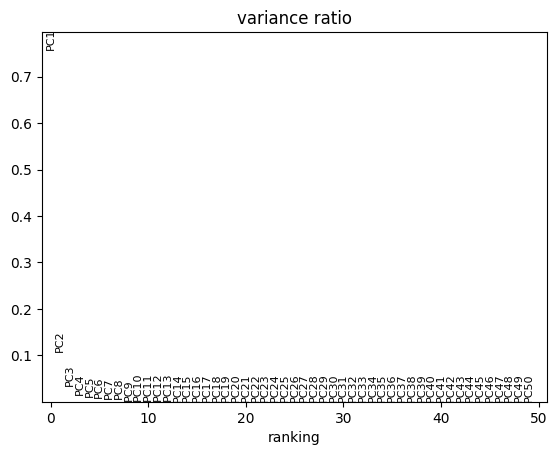

In [7]:
sc.pl.pca_variance_ratio(adata, log=False, n_pcs=50, show=False)

In [9]:
n_pcs_use = 30
X = adata.obsm["X_pca"].astype("float64")
ho = hm.run_harmony(X, adata.obs, "sample")

print("X_pca shape:", X.shape)
print("Harmony Z_corr shape:", ho.Z_corr.shape)

adata.obsm["X_pca_harmony"] = ho.Z_corr
adata.obsm["X_pca_harmony_use"] = adata.obsm["X_pca_harmony"][:, :n_pcs_use]

adata.write(f"{output_path}/adata30_after_pca_harmony.h5ad")


sc.pp.neighbors(
    adata,
    n_neighbors=15,
    use_rep="X_pca_harmony_use",
    metric="euclidean",
    random_state=0
)

adata.write(f"{output_path}/adata30_after_pca_harmony_neighbors.h5ad")

2026-04-13 08:35:05,379 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-04-13 08:35:05,380 - harmonypy - INFO -   Parameters:
2026-04-13 08:35:05,381 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-13 08:35:05,381 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-13 08:35:05,381 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-13 08:35:05,382 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-13 08:35:05,382 - harmonypy - INFO -     nclust: 100
2026-04-13 08:35:05,383 - harmonypy - INFO -     block_size: 0.05
2026-04-13 08:35:05,384 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
2026-04-13 08:35:05,384 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2.]
2026-04-13 08:35:05,385 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-13 08:35:05,385 - harmonypy - INFO -     verbose: True
2026-04-13

X_pca shape: (1103409, 50)
Harmony Z_corr shape: (1103409, 50)


/p1/zulab_users/jtian/anaconda3/envs/my_NewSA_py39/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [10]:
adata

AnnData object with n_obs × n_vars = 1103409 × 336
    obs: 'sample', 'x', 'y'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'spatial', 'X_pca', 'X_pca_harmony', 'X_pca_harmony_use'
    varm: 'PCs'
    layers: 'norm_1e4', 'norm_1e4_log1p', 'norm_1e4_log1p_scale', 'raw'
    obsp: 'distances', 'connectivities'

In [12]:
X_kmeans = adata.obsm["X_pca_harmony_use"]
n_clusters = 19

kmeans = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init="auto",
    random_state=0
)

adata.obs["kmeans"] = kmeans.fit_predict(X_kmeans).astype(str)
adata.obs["kmeans"] = adata.obs["kmeans"].astype("category")

print("KMeans n_clusters =", adata.obs["kmeans"].nunique())

# 保存
adata.write(f"{output_path}/adata30_after_pca_harmony_kmeans.h5ad")

KMeans n_clusters = 19


In [14]:
adata.obs['library_id']=adata.obs['sample'].copy()
parts = adata.obs["sample"].astype(str).str.extract(r"^([A-Za-z]+)(\d+)_")
adata.obs["condition"] = parts[0]
adata.obs["replicate"] = "Rep" + parts[1]
adata.obs["library_id"] = adata.obs["library_id"].astype(str)
adata.obs["condition"] = adata.obs["condition"].astype(str)
adata.obs["replicate"] = adata.obs["replicate"].astype(str)

In [15]:
adata.obs

,sample,x,y,kmeans,library_id,condition,replicate
ctrl1_0_pixel1,ctrl1_0,61072.238281,10187.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel2,ctrl1_0,61092.238281,10187.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel3,ctrl1_0,61112.238281,10187.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel4,ctrl1_0,60572.238281,10167.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel5,ctrl1_0,60592.238281,10167.917969,5,ctrl1_0,ctrl,Rep1
...,...,...,...,...,...,...,...
dn3_60_pixel58565,dn3_60,2359.611816,5964.661621,5,dn3_60,dn,Rep3
dn3_60_pixel58566,dn3_60,2379.611816,5964.661621,5,dn3_60,dn,Rep3
dn3_60_pixel58567,dn3_60,2399.611816,5964.661621,5,dn3_60,dn,Rep3
dn3_60_pixel58568,dn3_60,2419.611816,5964.661621,5,dn3_60,dn,Rep3


In [16]:
sc.tl.umap(adata, random_state=0)
adata.write(f"{output_path}/adata30_umap.h5ad")

sc.pl.umap(
    adata,
    color=["kmeans", "condition", "replicate", "library_id"],
    wspace=0.35,
    legend_loc="right margin",
    size=8,
    show=False
)
plt.savefig(
    os.path.join(output_path, "umap_kmeans_condition_batch.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# =========================
# 12. 按切片/文库统一颜色画 UMAP 子图
# =========================
cats = adata.obs["kmeans"].cat.categories.tolist()
cmap = plt.get_cmap("tab20", len(cats))
palette = {c: mpl.colors.to_hex(cmap(i)) for i, c in enumerate(cats)}

handles = [
    Line2D([0], [0], marker='o', color='w', label=c,
           markerfacecolor=palette[c], markersize=6)
    for c in cats
]

library_ids = sorted(adata.obs["library_id"].astype(str).unique().tolist())

ncols = 5
nrows = int(np.ceil(len(library_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

umap = adata.obsm["X_umap"]

for ax, lib in zip(axes, library_ids):
    idx = (adata.obs["library_id"].values.astype(str) == lib)
    colors = adata.obs.loc[idx, "kmeans"].map(palette).values
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=3, linewidths=0)
    ax.set_title(lib)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(
    os.path.join(output_path, "umap_by_library_kmeans.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# =========================
# 13. 按切片画空间分布图（x, y）
# =========================
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, lib in zip(axes, library_ids):
    idx = (adata.obs["library_id"].values.astype(str) == lib)
    colors = adata.obs.loc[idx, "kmeans"].map(palette).values
    ax.scatter(
        adata.obs.loc[idx, "x"].astype(float),
        adata.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    ax.invert_yaxis()
    ax.set_title(lib)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(
    os.path.join(output_path, "spatial_by_library_kmeans.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# 单独保存每个切片的空间图
os.makedirs(os.path.join(output_path, "spatial_by_slice"), exist_ok=True)

for lib in library_ids:
    idx = (adata.obs["library_id"].values.astype(str) == lib)
    colors = adata.obs.loc[idx, "kmeans"].map(palette).values

    plt.figure(figsize=(5, 5))
    plt.scatter(
        adata.obs.loc[idx, "x"].astype(float),
        adata.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    plt.gca().invert_yaxis()
    plt.title(lib)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, "spatial_by_slice", f"{lib}_spatial_kmeans.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

# =========================
# 14. 保存最终meta
# =========================
adata.obs.to_csv(f"{output_path}/final_obs_metadata_kmeans.csv")
print("Done.")

Done.


In [19]:
ctrl_merged=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden/ctrlIntensity_merged.csv", sep=";",index_col=0)
dn_merged=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden/dnIntensity_merged.csv", sep=";",index_col=0)

In [20]:
ctrl_merged

,57.0346,58.0302,59.0139,67.0191,68.0143,68.9977,69.0346,70.0061,70.0299,71.014,...,858.5247,859.534,860.536,861.5477,862.552,863.5618,864.5684,882.5853,884.5423,888.5584
ctrl1_0_pixel1,0.000000,0.000000,0.261729,0.000000,0.234178,0.551008,1.418844,0.000000,0.000000,1.838988,...,0.000000,0.103314,0.000000,0.192853,0.420143,0.172190,0.061988,0.110202,0.123977,0.082651
ctrl1_0_pixel2,0.000000,0.000000,0.140146,0.414068,0.203849,0.000000,0.847247,0.000000,0.872728,1.739085,...,0.197479,0.299403,0.000000,0.121035,0.000000,0.070073,0.089184,0.000000,0.165627,0.471400
ctrl1_0_pixel3,0.000000,0.258983,0.000000,0.000000,0.267077,0.000000,0.000000,0.000000,0.922628,2.363223,...,0.000000,0.000000,0.453221,0.000000,0.485594,0.000000,0.000000,0.000000,0.000000,0.226610
ctrl1_0_pixel4,0.201059,0.000000,0.000000,0.495467,0.359034,0.258505,0.517010,0.000000,0.883225,1.924424,...,0.157975,0.229782,0.093349,0.409299,0.258505,0.215421,0.330312,0.452383,0.215421,0.000000
ctrl1_0_pixel5,0.577206,0.000000,0.849775,0.000000,0.416871,0.000000,0.665390,0.000000,0.665390,0.801675,...,0.240502,0.000000,0.176368,0.168352,0.000000,0.000000,0.176368,0.144301,0.128268,0.368770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ctrl3_60_pixel50660,2.105920,0.399399,10.329899,2.178538,2.341928,3.521969,2.596091,2.995489,4.393384,39.013979,...,3.612742,5.627889,0.000000,5.754970,2.251156,3.558278,1.670212,2.723172,2.033302,1.343432
ctrl3_60_pixel50661,2.115093,0.459090,16.691198,1.278893,2.033112,2.541391,6.427259,3.033273,5.246742,49.745672,...,3.115253,4.640087,0.000000,6.033753,2.902104,3.672719,2.623371,1.869152,1.737983,2.180677
ctrl3_60_pixel50662,1.906487,2.017329,14.121301,2.793224,4.633206,2.815393,6.894387,1.529623,4.965732,41.831861,...,4.588869,5.918976,5.054406,8.623526,7.470767,4.655374,2.083834,1.950823,2.194676,1.950823
ctrl3_60_pixel50663,1.522979,3.635498,7.148176,0.000000,2.947701,4.323295,11.397779,0.000000,8.941361,30.975429,...,5.133913,11.299522,7.393818,9.604594,13.166400,7.614895,4.102218,6.091916,3.488113,2.751188


In [21]:
dn_merged

,57.0346,58.0302,59.0139,67.0191,68.0143,68.9977,69.0346,70.0061,70.0299,71.014,...,862.552,863.5618,864.5684,884.5423,888.5673,918.5629,919.5555,921.5991,923.615,946.5988
dn1_0_pixel1,0.000000,0.712215,0.000000,0.000000,1.035949,0.684466,0.434729,0.000000,0.786211,1.119195,...,0.000000,0.101745,0.203490,0.000000,0.000000,0.083246,0.000000,0.000000,0.000000,0.314484
dn1_0_pixel2,0.000000,1.836354,3.292773,1.308666,2.617332,2.385150,2.596225,0.000000,9.160663,4.411471,...,0.970946,0.000000,0.000000,0.253290,0.337720,0.000000,0.675441,0.274398,0.295505,0.844301
dn1_0_pixel3,0.000000,1.547361,0.000000,1.246902,0.480733,0.961467,0.000000,0.435665,3.365134,1.652521,...,0.000000,0.000000,0.540825,0.525802,0.240367,0.165252,0.000000,0.000000,0.420642,0.781192
dn1_0_pixel4,0.830629,0.540409,0.000000,0.000000,1.250948,0.000000,0.490371,0.230174,1.491129,1.681273,...,0.350265,0.000000,0.180136,0.470356,0.370280,0.000000,0.570432,0.320243,0.000000,1.401061
dn1_0_pixel5,0.000000,0.000000,0.000000,0.202554,0.920700,1.031184,0.000000,0.000000,1.086427,1.758538,...,0.000000,0.119691,0.082863,0.174933,0.239382,0.220968,0.000000,0.000000,0.211761,1.629640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dn3_60_pixel58565,0.000000,1.639123,10.191071,1.971699,1.330303,6.200162,9.454654,1.995455,9.787229,31.190855,...,5.178680,5.630032,2.399297,2.755628,0.000000,6.247673,2.470563,1.591613,2.826894,1.971699
dn3_60_pixel58566,0.000000,2.189291,9.793167,0.801437,1.446496,5.101829,5.121377,0.723248,5.101829,35.634617,...,3.362125,2.892991,2.267480,1.446496,1.896082,1.974271,2.091555,2.384763,3.850806,3.323031
dn3_60_pixel58567,0.796473,1.655414,7.917875,1.811585,2.186395,2.326949,3.263976,2.311332,3.982363,18.209550,...,2.326949,4.482111,1.546094,2.186395,0.000000,1.358689,1.155666,2.077076,2.217630,1.499243
dn3_60_pixel58568,0.455358,0.683037,6.342484,1.317285,2.016585,4.325900,3.886804,3.642863,4.651155,21.141614,...,5.025199,3.398921,1.967796,1.512439,1.479913,1.723855,2.715884,2.439417,1.707592,1.252234


In [22]:
adata.obs.rename(columns={"kmeans": "cluster"}, inplace=True)

In [ ]:
adata.obs

,sample,x,y,cluster,library_id,condition,replicate
ctrl1_0_pixel1,ctrl1_0,61072.238281,10187.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel2,ctrl1_0,61092.238281,10187.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel3,ctrl1_0,61112.238281,10187.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel4,ctrl1_0,60572.238281,10167.917969,5,ctrl1_0,ctrl,Rep1
ctrl1_0_pixel5,ctrl1_0,60592.238281,10167.917969,5,ctrl1_0,ctrl,Rep1
...,...,...,...,...,...,...,...
dn3_60_pixel58565,dn3_60,2359.611816,5964.661621,5,dn3_60,dn,Rep3
dn3_60_pixel58566,dn3_60,2379.611816,5964.661621,5,dn3_60,dn,Rep3
dn3_60_pixel58567,dn3_60,2399.611816,5964.661621,5,dn3_60,dn,Rep3
dn3_60_pixel58568,dn3_60,2419.611816,5964.661621,5,dn3_60,dn,Rep3


In [24]:
ctrl_cluster = adata.obs.loc[
    adata.obs["library_id"].astype(str).str.startswith("ctrl"),
    "cluster"
].reset_index(drop=True)

dn_cluster = adata.obs.loc[
    adata.obs["library_id"].astype(str).str.startswith("dn"),
    "cluster"
].reset_index(drop=True)
if len(ctrl_cluster) != len(ctrl_merged):
    raise ValueError(
        f"ctrl 的 cluster 数量 ({len(ctrl_cluster)}) "
        f"与 ctrl_merged 行数 ({len(ctrl_merged)}) 不一致"
    )

if len(dn_cluster) != len(dn_merged):
    raise ValueError(
        f"dn 的 cluster 数量 ({len(dn_cluster)}) "
        f"与 dn_merged 行数 ({len(dn_merged)}) 不一致"
    )

ctrl_merged.insert(0, "cluster", ctrl_cluster.to_numpy())
dn_merged.insert(0, "cluster", dn_cluster.to_numpy())
print(ctrl_merged.iloc[:5,:5])
print(dn_merged.iloc[:5,:5])

               cluster   57.0346   58.0302   59.0139   67.0191
ctrl1_0_pixel1       5  0.000000  0.000000  0.261729  0.000000
ctrl1_0_pixel2       5  0.000000  0.000000  0.140146  0.414068
ctrl1_0_pixel3       5  0.000000  0.258983  0.000000  0.000000
ctrl1_0_pixel4       5  0.201059  0.000000  0.000000  0.495467
ctrl1_0_pixel5       5  0.577206  0.000000  0.849775  0.000000
             cluster   57.0346   58.0302   59.0139   67.0191
dn1_0_pixel1       5  0.000000  0.712215  0.000000  0.000000
dn1_0_pixel2       5  0.000000  1.836354  3.292773  1.308666
dn1_0_pixel3       5  0.000000  1.547361  0.000000  1.246902
dn1_0_pixel4       5  0.830629  0.540409  0.000000  0.000000
dn1_0_pixel5       5  0.000000  0.000000  0.000000  0.202554


In [25]:
ctrl_mz_cols = [c for c in ctrl_merged.columns if c != "cluster"]
ctrl_mz_cols = sorted(ctrl_mz_cols, key=lambda x: float(x))
ctrl_merged = ctrl_merged[["cluster"] + ctrl_mz_cols]

ctrl_tmp = ctrl_merged.copy()
ctrl_tmp["group"] = ctrl_tmp.index.to_series().str.replace(r"_pixel\d+$", "", regex=True)
ctrl_cluster_mean = ctrl_tmp.groupby(
    ["group", "cluster"],
    sort=False
)[ctrl_mz_cols].mean()
ctrl_cluster_mean.index = [
    f"{group}_cluster{cluster}"
    for group, cluster in ctrl_cluster_mean.index
]
ctrl_sort_df = ctrl_cluster_mean.copy()
ctrl_parts = ctrl_sort_df.index.to_series().str.extract(
    r"^ctrl(\d+)_(\d+)_cluster(\d+)$"
)
ctrl_sort_df["_sample_num"] = ctrl_parts[0].astype(int)
ctrl_sort_df["_time"] = ctrl_parts[1].astype(int)
ctrl_sort_df["_cluster"] = ctrl_parts[2].astype(int)
ctrl_sort_df = ctrl_sort_df.sort_values(
    by=["_sample_num", "_cluster", "_time"],
    kind="stable"
)
ctrl_cluster_mean = ctrl_sort_df.drop(
    columns=["_sample_num", "_time", "_cluster"]
)
print(ctrl_cluster_mean.iloc[:10,:5])

                    57.0346   58.0302   59.0139   67.0191   68.0143
ctrl1_0_cluster0   0.613534  1.086141  3.953433  1.077273  2.007209
ctrl1_15_cluster0  0.662451  1.093980  4.271147  1.128884  1.609857
ctrl1_30_cluster0  0.682228  1.007503  4.621412  1.162150  1.442770
ctrl1_45_cluster0  0.703750  0.998834  4.818646  1.237574  1.444523
ctrl1_60_cluster0  0.740025  1.135110  5.135991  1.418421  1.404880
ctrl1_0_cluster1   0.658168  1.112414  3.912688  1.077955  2.429582
ctrl1_15_cluster1  0.705189  1.229334  4.504802  1.160626  2.056774
ctrl1_30_cluster1  0.684299  1.035965  4.635500  1.138216  1.650213
ctrl1_45_cluster1  0.760148  1.139648  5.208368  1.280747  1.689758
ctrl1_60_cluster1  0.782898  1.139191  5.454587  1.375409  1.679533


In [26]:
dn_mz_cols = [c for c in dn_merged.columns if c != "cluster"]
dn_mz_cols = sorted(dn_mz_cols, key=lambda x: float(x))
dn_merged = dn_merged[["cluster"] + dn_mz_cols]

dn_tmp = dn_merged.copy()
dn_tmp["group"] = dn_tmp.index.to_series().str.replace(r"_pixel\d+$", "", regex=True)
dn_cluster_mean = dn_tmp.groupby(
    ["group", "cluster"],
    sort=False
)[dn_mz_cols].mean()
dn_cluster_mean.index = [
    f"{group}_cluster{cluster}"
    for group, cluster in dn_cluster_mean.index
]
dn_sort_df = dn_cluster_mean.copy()

dn_parts = dn_sort_df.index.to_series().str.extract(
    r"^dn(\d+)_(\d+)_cluster(\d+)$"
)

dn_sort_df["_sample_num"] = dn_parts[0].astype(int)
dn_sort_df["_time"] = dn_parts[1].astype(int)
dn_sort_df["_cluster"] = dn_parts[2].astype(int)

dn_sort_df = dn_sort_df.sort_values(
    by=["_sample_num", "_cluster", "_time"],
    kind="stable"
)

dn_cluster_mean = dn_sort_df.drop(
    columns=["_sample_num", "_time", "_cluster"]
)
print(dn_cluster_mean.iloc[:10,:5])


                  57.0346   58.0302   59.0139   67.0191   68.0143
dn1_0_cluster0   0.657367  0.948165  4.870227  1.069106  1.860603
dn1_15_cluster0  0.683978  1.197205  4.832645  1.234700  1.690448
dn1_30_cluster0  0.727214  1.167489  5.146392  1.228284  1.575136
dn1_45_cluster0  0.798468  1.112564  5.365241  1.312929  1.513424
dn1_60_cluster0  0.784421  1.048009  5.497306  1.512820  1.441182
dn1_0_cluster1   0.725855  1.060166  4.980846  1.130702  2.355180
dn1_15_cluster1  0.717485  1.157854  4.598586  1.226875  1.713621
dn1_30_cluster1  0.785142  1.281332  5.185580  1.287660  1.783196
dn1_45_cluster1  0.803960  1.253045  5.448531  1.429061  1.743348
dn1_60_cluster1  0.762187  1.071184  5.287266  1.465387  1.474841


In [27]:
ctrl_cluster_mean.to_csv(f'{output_path}/ctrlIntensityMeanByCluster.csv')
dn_cluster_mean.to_csv(f'{output_path}/dnIntensityMeanByCluster.csv')

In [28]:
def linreg_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan

    xm = x.mean()
    ym = y.mean()
    dx = x - xm
    dy = y - ym

    varx = np.sum(dx * dx)
    if varx == 0:
        return np.nan, np.nan, np.nan, np.nan

    slope = np.sum(dx * dy) / varx
    intercept = ym - slope * xm

    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - ym) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # y=0 时 x 截距：x0 = -b/a；取绝对值
    x0_abs = np.abs(-intercept / slope) if slope != 0 else np.nan
    return slope, intercept, r2, x0_abs

In [29]:
def build_linreg_result(df):
    """
    df 的行名格式：
    ctrl1_0_cluster0 / dn1_15_cluster2 这类
    列名为 m/z
    """
    tmp = df.copy()

    # 解析行名：样本号、时间、cluster
    parts = tmp.index.to_series().str.extract(
        r"^([A-Za-z]+\d+)_(\d+)_cluster(\d+)$"
    )

    tmp["_sample"] = parts[0]
    tmp["_time"] = parts[1].astype(int)
    tmp["_cluster"] = parts[2].astype(int)

    # m/z 列
    mz_cols = [c for c in tmp.columns if c not in ["_sample", "_time", "_cluster"]]
    mz_cols = sorted(mz_cols, key=lambda x: float(x))

    result_rows = []

    # 按 sample + cluster 分组
    for (sample, cluster), sub in tmp.groupby(["_sample", "_cluster"], sort=False):
        sub = sub.sort_values("_time")

        # 这里 x 实际上就是 [0,15,30,45,60]
        x = sub["_time"].to_numpy(dtype=float)

        for mz in mz_cols:
            y = sub[mz].to_numpy(dtype=float)
            slope, intercept, r2, x0_abs = linreg_stats(x, y)

            result_rows.append({
                "sample": sample,
                "mz": float(mz),
                "cluster": int(cluster),
                "slope": slope,
                "intercept": intercept,
                "r2": r2,
                "x0_abs": x0_abs
            })

    result_df = pd.DataFrame(result_rows)

    # 排序：先 sample，再 cluster，再 mz
    parts2 = result_df["sample"].str.extract(r"^([A-Za-z]+)(\d+)$")
    result_df["_prefix"] = parts2[0]
    result_df["_sample_num"] = parts2[1].astype(int)

    result_df = result_df.sort_values(
        by=["_prefix", "_sample_num", "cluster", "mz"],
        kind="stable"
    ).drop(columns=["_prefix", "_sample_num"])

    result_df = result_df.reset_index(drop=True)
    return result_df

In [30]:
ctrl_linreg_result = build_linreg_result(ctrl_cluster_mean)
dn_linreg_result = build_linreg_result(dn_cluster_mean)

print(ctrl_linreg_result.head())
print(dn_linreg_result.head())

  sample       mz  cluster     slope  intercept        r2        x0_abs
0  ctrl1  57.0346        0  0.001962   0.621541  0.973384    316.809367
1  ctrl1  58.0302        0  0.000019   1.063756  0.000056  57172.453668
2  ctrl1  59.0139        0  0.019417   3.977603  0.993603    204.847039
3  ctrl1  67.0191        0  0.005273   1.046663  0.886787    198.485274
4  ctrl1  68.0143        0 -0.009133   1.855846  0.747060    203.195961
  sample       mz  cluster     slope  intercept        r2       x0_abs
0    dn1  57.0346        0  0.002457   0.656570  0.902726   267.189248
1    dn1  58.0302        0  0.000767   1.071677  0.033275  1397.263753
2    dn1  59.0139        0  0.011912   4.785012  0.923596   401.707215
3    dn1  67.0191        0  0.006438   1.078436  0.895449   167.518626
4    dn1  68.0143        0 -0.006772   1.819331  0.954427   268.637909


In [32]:
ctrl_linreg_result.to_csv(f'{output_path}/ctrl_linreg_result.csv',index=False)
dn_linreg_result.to_csv(f'{output_path}/dn_linreg_result.csv',index=False)

In [31]:
ctrl_r2_mean = (
    ctrl_linreg_result
    .groupby(["sample", "mz"], as_index=False)["r2"]
    .mean()
    .rename(columns={"r2": "mean_r2"})
)

ctrl_good = ctrl_r2_mean[ctrl_r2_mean["mean_r2"] >= 0.9].copy()

# 每个样本筛出来多少个代谢物
ctrl_count = (
    ctrl_good
    .groupby("sample", as_index=False)
    .size()
    .rename(columns={"size": "n_metabolites_r2_ge_0.9"})
)

print("ctrl_good:")
print(ctrl_good.head())

print("ctrl_count:")
print(ctrl_count)


dn_r2_mean = (
    dn_linreg_result
    .groupby(["sample", "mz"], as_index=False)["r2"]
    .mean()
    .rename(columns={"r2": "mean_r2"})
)

dn_good = dn_r2_mean[dn_r2_mean["mean_r2"] >= 0.9].copy()

dn_count = (
    dn_good
    .groupby("sample", as_index=False)
    .size()
    .rename(columns={"size": "n_metabolites_r2_ge_0.9"})
)

print("dn_good:")
print(dn_good.head())

print("dn_count:")
print(dn_count)

ctrl_good:
   sample       mz   mean_r2
2   ctrl1  59.0139  0.945292
9   ctrl1  71.0140  0.911442
10  ctrl1  71.0503  0.907981
14  ctrl1  73.0294  0.932732
15  ctrl1  74.0246  0.931969
ctrl_count:
  sample  n_metabolites_r2_ge_0.9
0  ctrl1                      216
1  ctrl2                      143
2  ctrl3                      347
dn_good:
   sample        mz   mean_r2
34    dn1   88.0405  0.930751
35    dn1   89.0246  0.947321
46    dn1   96.9696  0.940382
52    dn1   98.9740  0.911034
56    dn1  100.0042  0.903805
dn_count:
  sample  n_metabolites_r2_ge_0.9
0    dn1                       91
1    dn2                      158
2    dn3                      140
